# 01 — Demographics

Who is in Madden NFL 26? This notebook profiles the ~2,015 rostered players in the Week 15 ratings
export: age, position mix, college pedigree, body type (height/weight) by position, experience, and
dominant hand.

Data: `data/processed/madden_clean.csv` (built by `scripts/fetch_madden.py` + `scripts/build_dataset.py`
from the [`flynn28/madden-26-week-15-player-ratings`](https://www.kaggle.com/datasets/flynn28/madden-26-week-15-player-ratings)
Kaggle dataset).

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/madden_clean.csv")
print(df.shape)
df.head(3)

(2015, 70)


,id,name,birthday,age,college,avatar,team,position,number,years_pro,dominant_hand,abilities,running_style,height,weight,strength,stamina,injury,toughness,jumping,speed,acceleration,agility,change_of_direction,rating,...,run_block_power,lead_block,impact_blocking,tackle,pursuit,hit_power,block_shedding,power_moves,finesse_moves,man_coverage,zone_coverage,press,throw_power,throw_accuracy_short,throw_accuracy_mid,throw_accuracy_deep,throw_on_the_run,throw_under_pressure,play_action,break_sack,kick_power,kick_accuracy,kick_return,position_group,name_norm
0,21586,Ja'Marr Chase,2000-03-01,25,LSU,https://ratings-images-prod.pulse.ea.com/madde...,Cincinnati Bengals,Wide Receiver,1,4,Right,"['Double Me', 'Mid In Elite', 'Runoff Elite', ...",Default,72,205,73,96,92,88,98,95,94,92,97,99,...,34,27,46,39,36,27,37,10,10,13,17,15,33,20,15,10,19,22,10,29,24,17,60,WR,ja'marr chase
1,13197,Josh Allen,1996-05-21,29,Wyoming,https://ratings-images-prod.pulse.ea.com/madde...,Buffalo Bills,Quarterback,17,7,Right,"['Bazooka', 'Pass Lead Elite', 'Fastbreak', 'D...",Default Stride Bread Loaf,77,237,81,98,99,98,92,88,91,85,82,99,...,10,17,26,32,33,11,23,9,9,12,18,9,98,97,87,90,99,94,97,98,22,14,13,QB,josh allen
2,927,Lane Johnson,1990-05-08,35,Oklahoma,https://ratings-images-prod.pulse.ea.com/madde...,Philadelphia Eagles,Right Tackle,65,12,Right,"['Nasty Streak', 'Fool Me Once']",Default,78,325,93,88,84,91,82,77,78,75,58,99,...,98,96,95,60,55,60,56,53,60,12,20,10,65,59,54,50,52,41,39,39,25,22,10,OL,lane johnson


## Position groups

Madden's roster export uses granular position labels (e.g. `Left Edge`/`Right Edge` instead of a single
`DE`, `Mike/Sam/Weak Backer` instead of `LB`). We collapse these into the same broad `position_group`
buckets used later for cross-referencing real-world stats (`QB`, `RB`, `WR`, `TE`, `OL`, `EDGE`, `DL`,
`LB`, `DB`, `ST`).

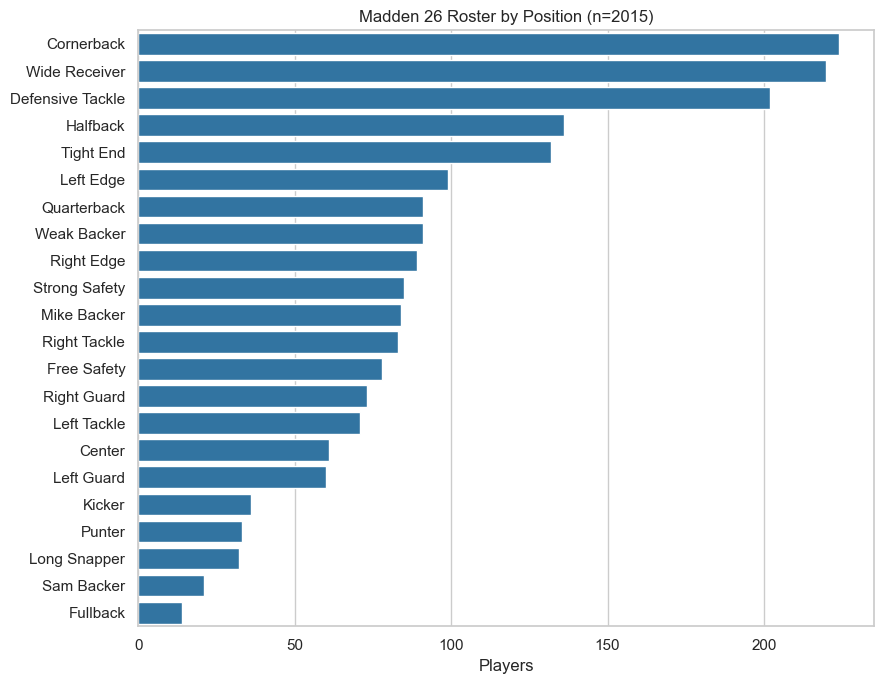

In [2]:
pos_counts = df["position"].value_counts()
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=pos_counts.values, y=pos_counts.index, ax=ax, color="#1f77b4")
ax.set_title(f"Madden 26 Roster by Position (n={len(df)})")
ax.set_xlabel("Players")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

position_group
DB      387
OL      348
WR      220
DL      202
LB      196
EDGE    188
RB      150
TE      132
ST      101
QB       91
Name: count, dtype: int64


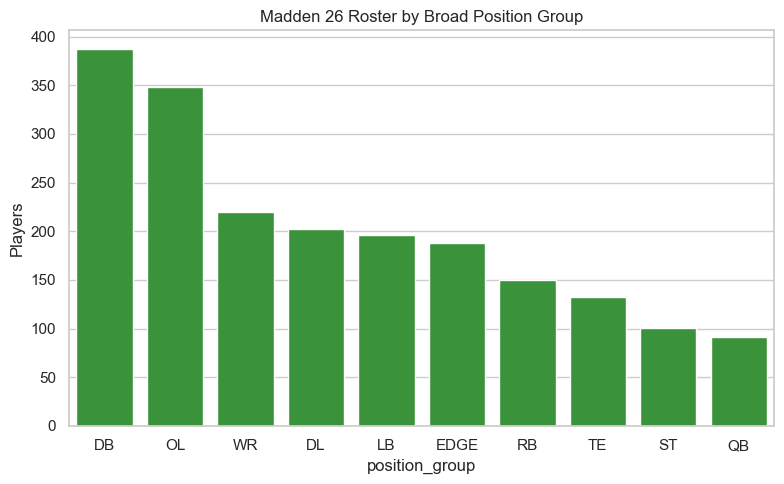

In [3]:
group_counts = df["position_group"].value_counts()
print(group_counts)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=group_counts.index, y=group_counts.values, ax=ax, color="#2ca02c")
ax.set_title("Madden 26 Roster by Broad Position Group")
ax.set_ylabel("Players")
plt.tight_layout()
plt.show()

**Takeaway:** cornerback, wide receiver, and defensive tackle are the deepest individual position
labels (~200+ each), but once collapsed into broad groups, offensive line (`OL`, 5 spots x 32 teams) and
defensive back (`DB`, corners + both safety spots) are the largest groups on the roster — consistent with
these being the positions where teams carry the most bodies (5-man O-line rotations, base + nickel/dime DB
packages).

## Age distribution

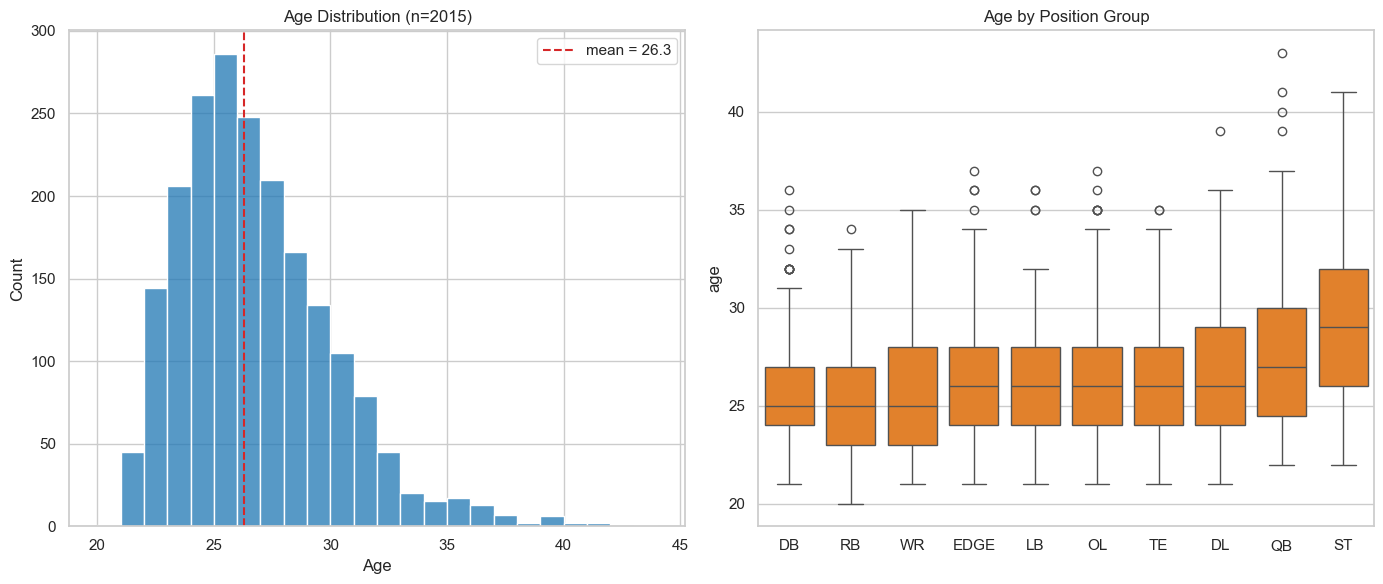

count    2015.000000
mean       26.294293
std         3.284468
min        20.000000
25%        24.000000
50%        26.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

position_group
DB      25.0
RB      25.0
WR      25.0
EDGE    26.0
LB      26.0
OL      26.0
TE      26.0
DL      26.0
QB      27.0
ST      29.0
Name: age, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df["age"], bins=range(20, 45), ax=axes[0], color="#1f77b4")
axes[0].set_title(f"Age Distribution (n={len(df)})")
axes[0].set_xlabel("Age")
axes[0].axvline(df["age"].mean(), color="#d62728", ls="--", label=f"mean = {df['age'].mean():.1f}")
axes[0].legend()

order = df.groupby("position_group")["age"].median().sort_values().index
sns.boxplot(data=df, x="position_group", y="age", order=order, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Age by Position Group")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print(df["age"].describe())
print()
print(df.groupby("position_group")["age"].median().sort_values())

**Takeaway:** the median Madden roster age is 26, typical of an NFL career shape (most players are
out of the league by their early 30s). Specialists (kickers/punters/long snappers, median 29) and
quarterbacks (median 27) skew oldest — both reward experience/processing/technique over the raw
explosiveness that fades fastest and both have historically long career tails (kickers and pocket
passers can play into their late 30s-40s) — while running backs, defensive backs, and receivers skew
youngest (median 25), matching the athletic, high-collision positions with the shortest average career
length.

## Experience (years pro)

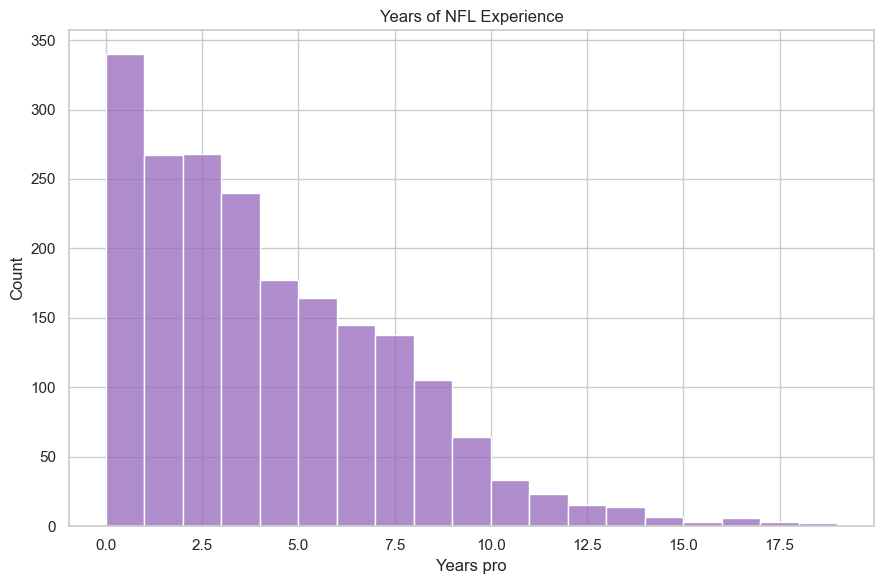

count    2015.000000
mean        3.768734
std         3.290339
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        20.000000
Name: years_pro, dtype: float64
Rookies (years_pro == 0): 340 (16.9%)


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df["years_pro"], bins=range(0, 20), ax=ax, color="#9467bd")
ax.set_title("Years of NFL Experience")
ax.set_xlabel("Years pro")
plt.tight_layout()
plt.show()

print(df["years_pro"].describe())
print(f"Rookies (years_pro == 0): {(df['years_pro'] == 0).sum()} ({100 * (df['years_pro'] == 0).mean():.1f}%)")

**Takeaway:** the distribution is heavily right-skewed — most players have 0-5 years of experience,
with a long thin tail of 10+ year veterans, mirroring the NFL's short average career length (rosters are
constantly refreshed by the draft/undrafted free agency).

## College pedigree

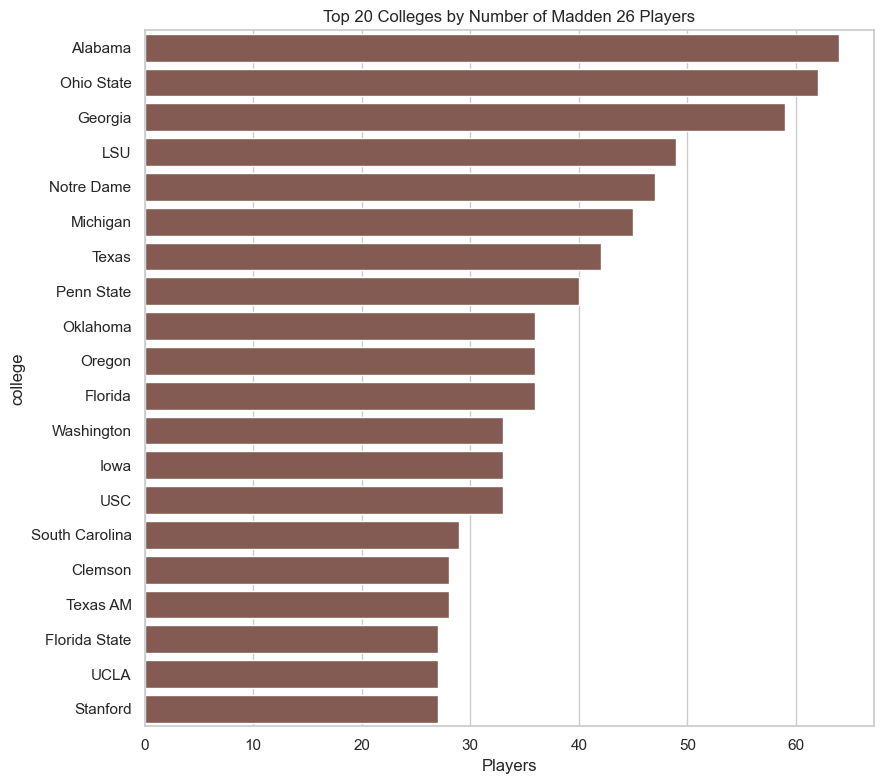

237 distinct colleges represented
Top 20 colleges account for 38.8% of all rostered players


In [6]:
top_colleges = df["college"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=top_colleges.values, y=top_colleges.index, ax=ax, color="#8c564b")
ax.set_title("Top 20 Colleges by Number of Madden 26 Players")
ax.set_xlabel("Players")
plt.tight_layout()
plt.show()

n_colleges = df["college"].nunique()
print(f"{n_colleges} distinct colleges represented")
print(f"Top 20 colleges account for {100 * top_colleges.sum() / len(df):.1f}% of all rostered players")

**Takeaway:** blue-blood college football programs (Alabama, Ohio State, Georgia, LSU) dominate NFL
roster representation, consistent with their recruiting/development pipelines and general college football
polling — the top 20 programs alone supply a large share of the entire league despite there being 250+
FBS/FCS programs that produce NFL talent.

## Height & weight by position

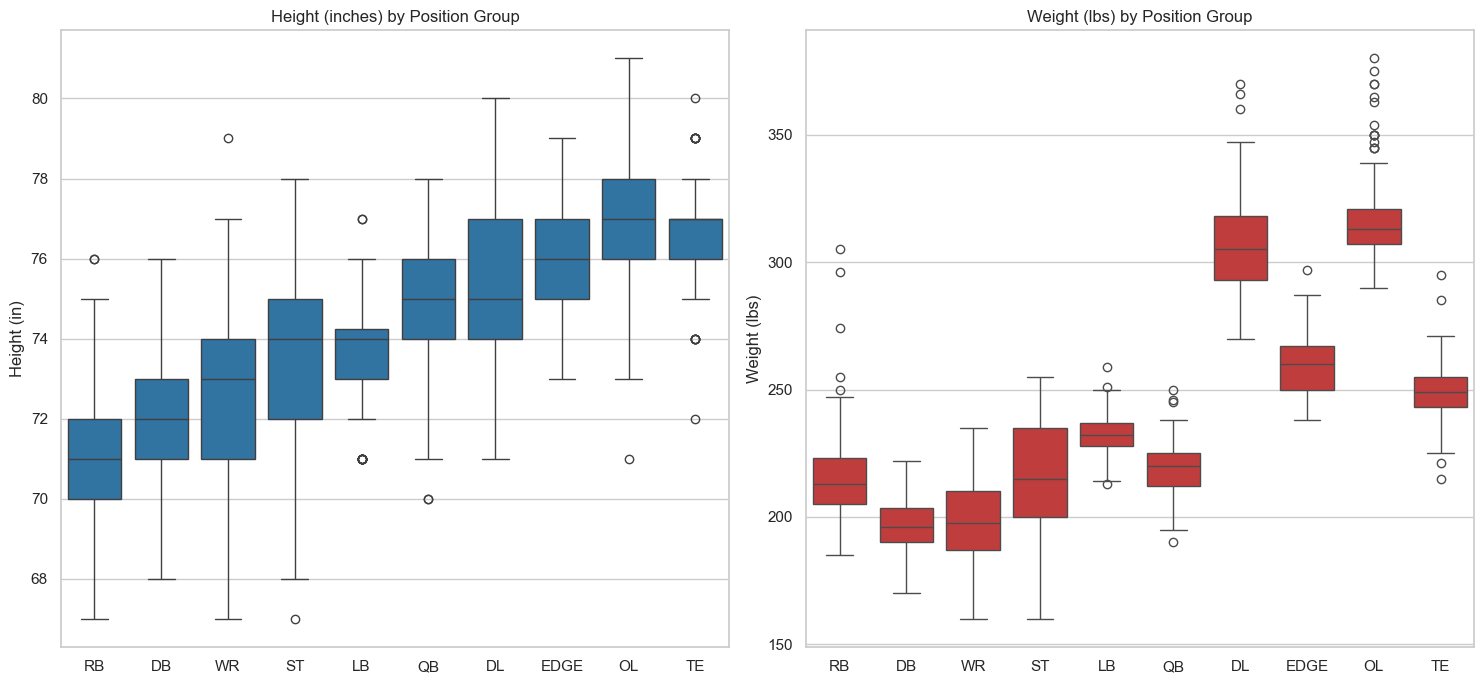

                height  weight
position_group                
DB                72.0   196.0
WR                73.0   197.5
RB                71.0   213.0
ST                74.0   215.0
QB                75.0   220.0
LB                74.0   232.0
TE                77.0   249.0
EDGE              76.0   260.0
DL                75.0   305.0
OL                77.0   313.0


In [7]:
df["height_ft_in"] = df["height"].apply(lambda h: f"{h // 12}'{h % 12}\"")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

order = df.groupby("position_group")["height"].median().sort_values().index
sns.boxplot(data=df, x="position_group", y="height", order=order, ax=axes[0], color="#1f77b4")
axes[0].set_title("Height (inches) by Position Group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Height (in)")

sns.boxplot(data=df, x="position_group", y="weight", order=order, ax=axes[1], color="#d62728")
axes[1].set_title("Weight (lbs) by Position Group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Weight (lbs)")

plt.tight_layout()
plt.show()

print(df.groupby("position_group")[["height", "weight"]].median().sort_values("weight"))

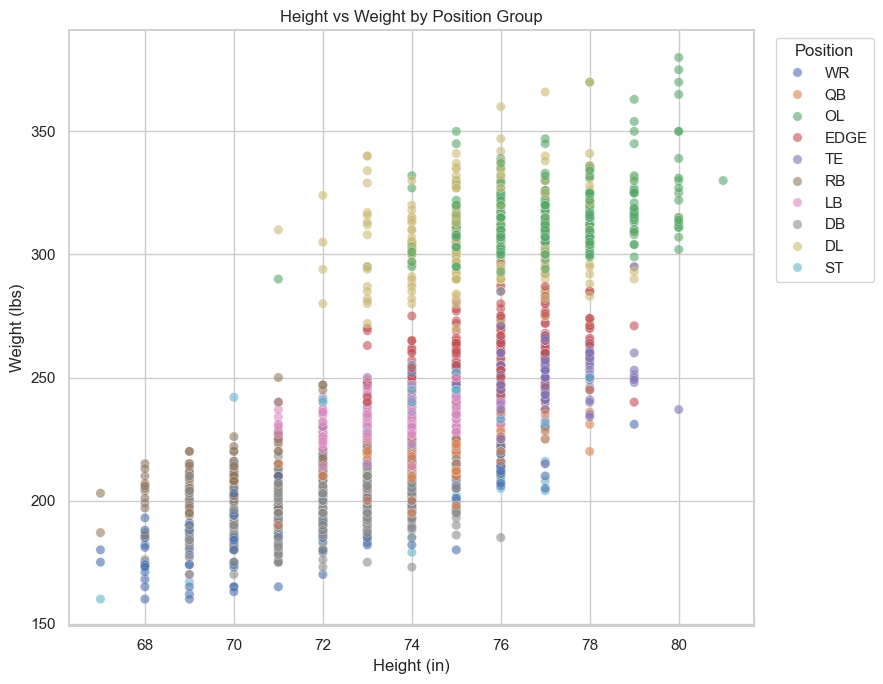

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=df, x="height", y="weight", hue="position_group",
    alpha=0.6, s=45, edgecolor="white", linewidth=0.3, ax=ax,
)
ax.set_title("Height vs Weight by Position Group")
ax.set_xlabel("Height (in)")
ax.set_ylabel("Weight (lbs)")
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Takeaway:** body type separates cleanly by position group, exactly as expected from football
positional archetypes — offensive line is by far the tallest and heaviest group (median well over 300 lbs),
defensive backs and wide receivers are the leanest and shortest, and quarterbacks/tight ends/edge rushers
sit in between in a fairly tight height band but a wide weight band. The height-vs-weight scatter shows
almost no overlap between OL and the skill positions — Madden's body attributes are internally consistent
with real football body types.

## Dominant hand

dominant_hand
Right    1963
Left       52
Name: count, dtype: int64
2.6% left-handed


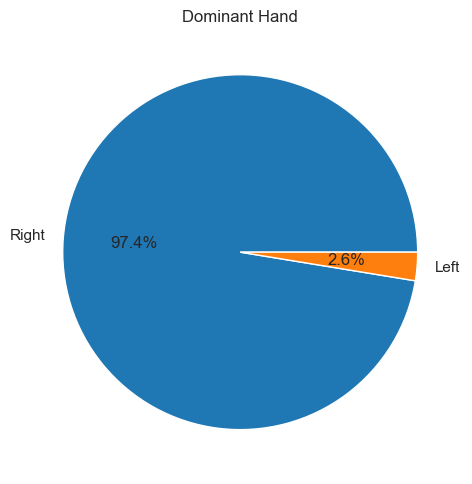

In [9]:
hand_counts = df["dominant_hand"].value_counts()
print(hand_counts)
print(f"{100 * hand_counts.get('Left', 0) / len(df):.1f}% left-handed")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(hand_counts.values, labels=hand_counts.index, autopct="%1.1f%%", colors=["#1f77b4", "#ff7f0e"])
ax.set_title("Dominant Hand")
plt.tight_layout()
plt.show()

**Takeaway:** only 2.6% of Madden 26 players are left-handed, well below the general-population rate
(~10%) — the opposite of what a no-selection-effect null hypothesis would predict. This lines up with a
well-documented real football phenomenon: left-handed quarterbacks are actively selected against at every
level of the sport (offensive line and route-running conventions are built around a right-handed passer),
and that selection pressure appears to bleed into the wider roster-building culture rather than being
confined to just the QB position.

## Summary

- Position group sizes reflect real NFL roster construction: offensive line and defensive back are the
  deepest broad groups.
- Age and experience distributions match the NFL's short-career-length reality: young, right-skewed, with
  RBs aging out earliest and QBs/OL lasting longest.
- A small number of blue-blood college programs supply a disproportionate share of NFL rosters.
- Body type (height/weight) cleanly separates by position group with almost no overlap between line and
  skill positions, suggesting Madden's physical attributes are grounded in real-world body types rather
  than arbitrary per-player assignment.
- Dominant hand roughly matches the general population rate, with no evidence of position-driven selection
  effects.